In [4]:
import os


print('\n'.join([
    os.path.join(root, f)
    for root, _, files in os.walk('./input')
    for f in files
]))

import numpy as np
import pandas as pd

./input/spaceship-titanic.zip
./input/sample_submission.csv
./input/test.csv
./input/train.csv


In [6]:
from ydata_profiling import ProfileReport

In [5]:
train =pd.read_csv('./input/train.csv')
test = pd.read_csv('./input/test.csv')
sample_submission = pd.read_csv('./input/sample_submission.csv')

In [10]:
train.head()


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [21]:
train.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


In [11]:
sample_submission.head()

,PassengerId,Transported
0,0013_01,False
1,0018_01,False
2,0019_01,False
3,0021_01,False
4,0023_01,False


In [7]:
profile = ProfileReport(train, title="Spaceship Titanic Profiling Report")

#Notebookには表示せず、ファイルに保存する
profile.to_file("SpaceshipTitanicReport.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 14/14 [00:00<00:00, 172.95it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [14]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

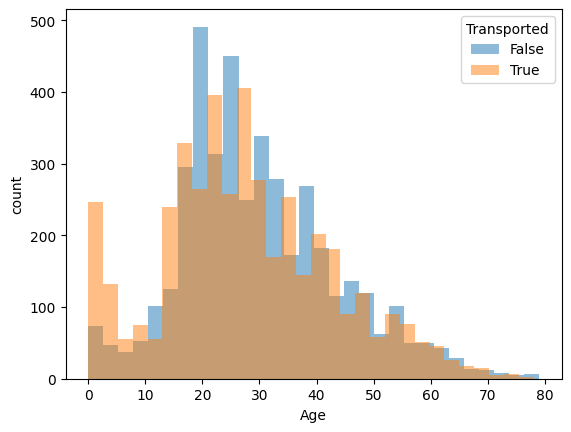

In [17]:
plt.hist(train.loc[train['Transported'] == False, 'Age'].dropna(), bins=30, alpha=0.5, label='False')
plt.hist(train.loc[train['Transported'] == True, 'Age'].dropna(), bins=30, alpha=0.5, label='True')
plt.xlabel('Age')
plt.ylabel('count')
plt.legend(title='Transported')
plt.show()
#子供、老人はTrueの割合が高い、中年はFalseの割合が高い

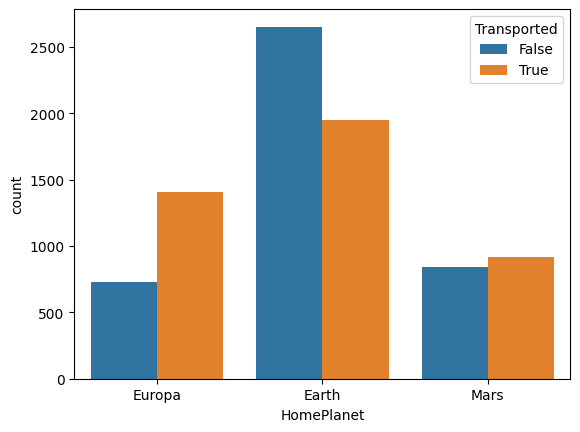

In [18]:
sns.countplot(x='HomePlanet', hue='Transported', data=train)
plt.show()

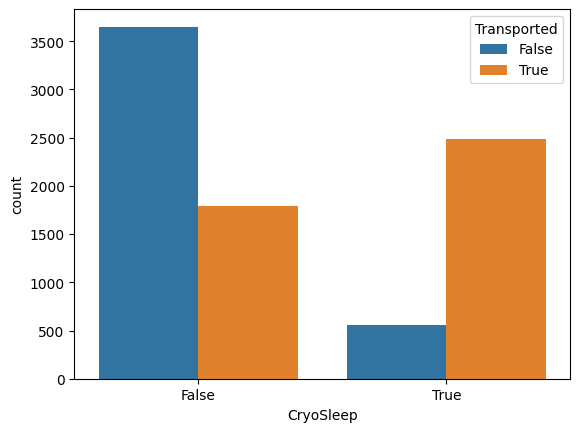

In [22]:
sns.countplot(x='CryoSleep', hue='Transported', data=train)
plt.show()

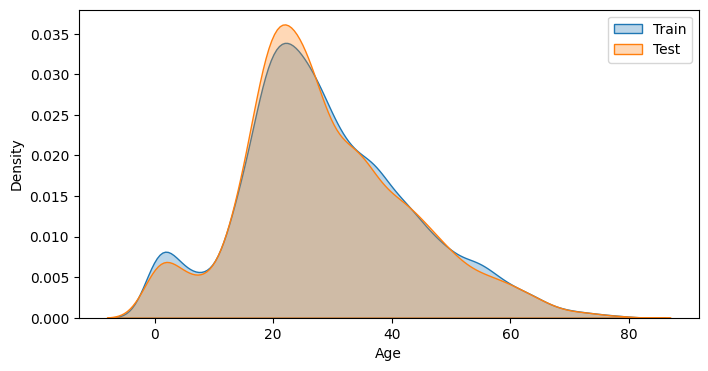

KS Statistic: 0.0190
P-value: 2.5636e-01
分布は概ね似ています。


In [24]:
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp

plt.figure(figsize=(8, 4))
# DataFrame 全体ではなく列（1次元）を渡す
sns.kdeplot(train['Age'].dropna(), label='Train', fill=True, alpha=0.3)
sns.kdeplot(test['Age'].dropna(), label='Test', fill=True, alpha=0.3)
plt.legend()
plt.show()

# 1次元配列で KS 検定
statistic, p_value = ks_2samp(train['Age'].dropna(), test['Age'].dropna())

print(f"KS Statistic: {statistic:.4f}")
print(f"P-value: {p_value:.4e}")

if p_value < 0.05:
    print("⚠ 注意: 分布が統計的に有意に異なります！")
else:
    print("分布は概ね似ています。")

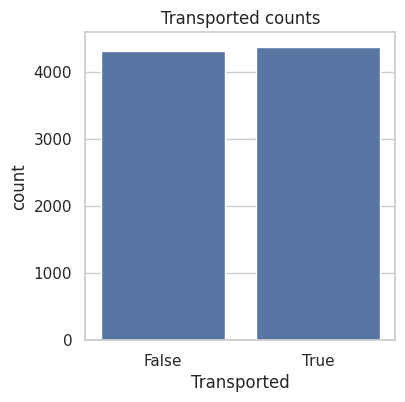

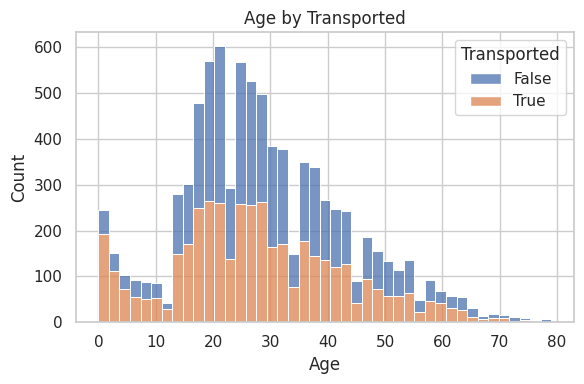

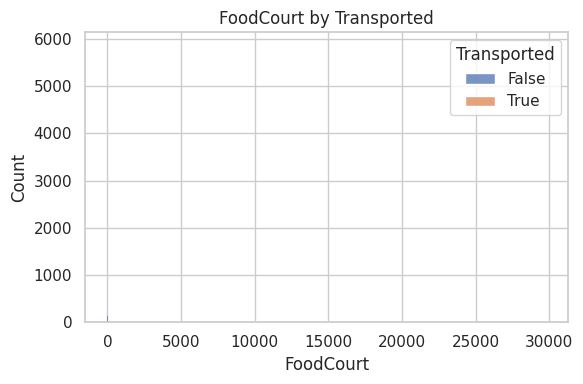

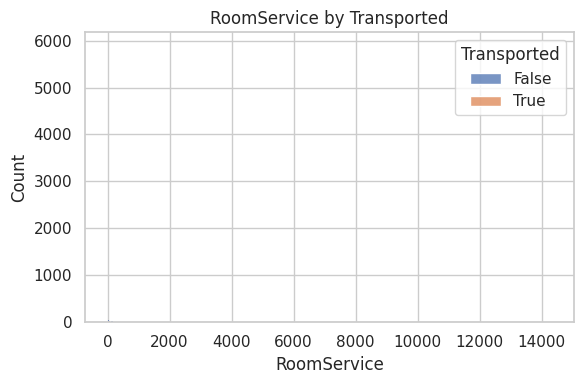

/home/naoki/miniforge3/envs/myenv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


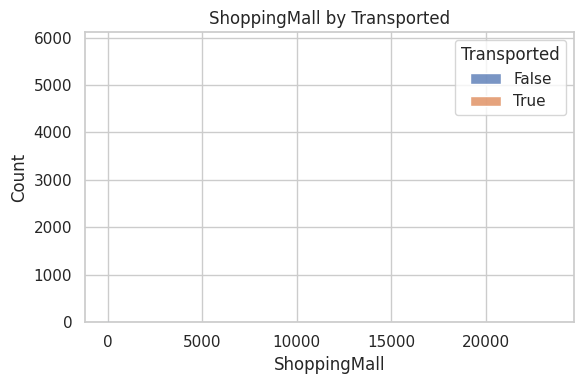

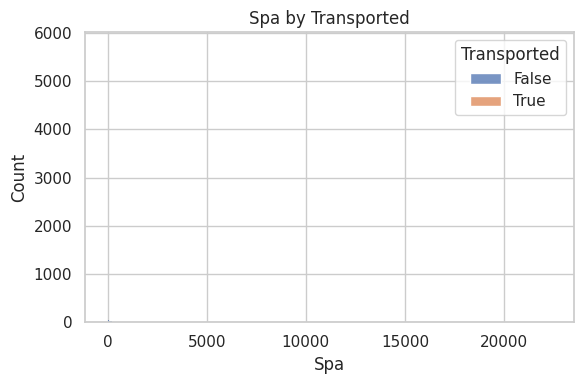

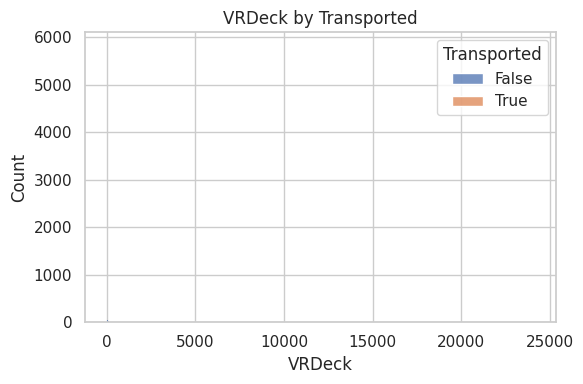

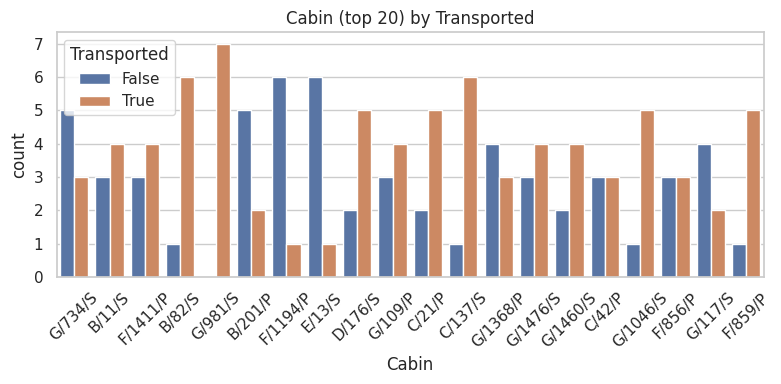

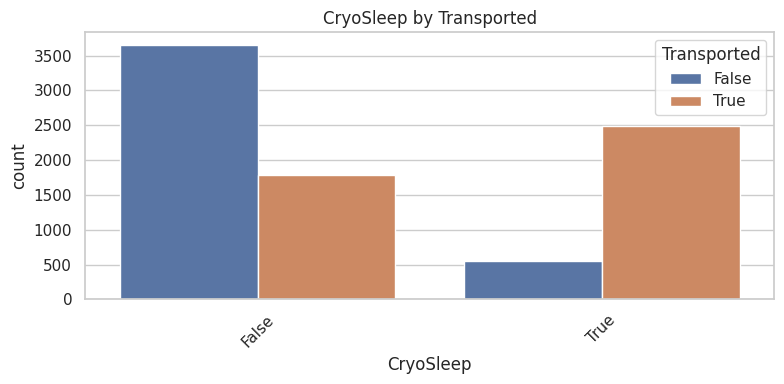

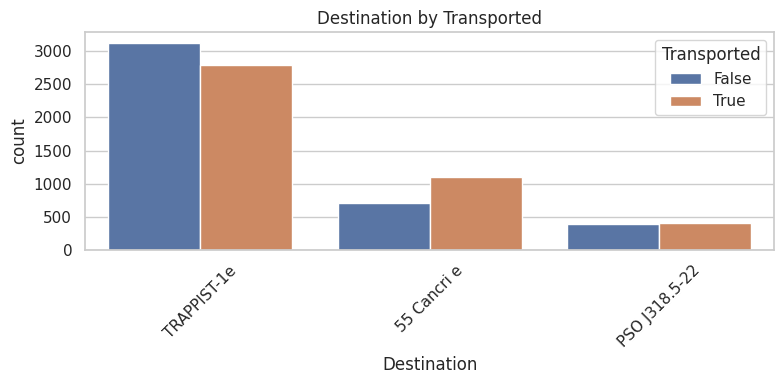

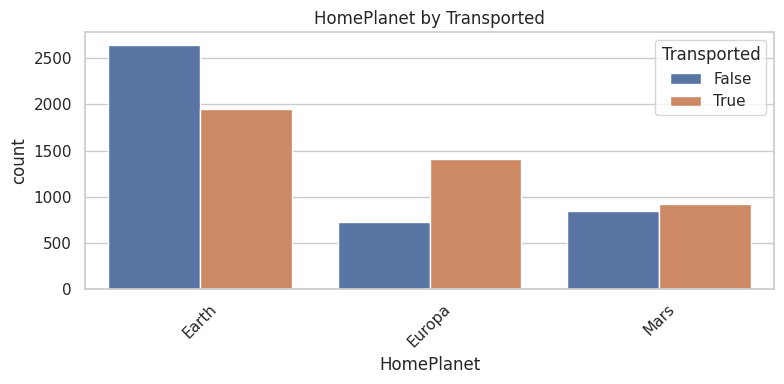

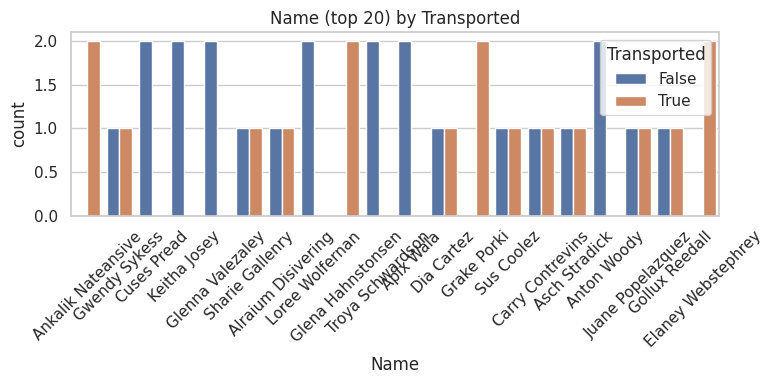

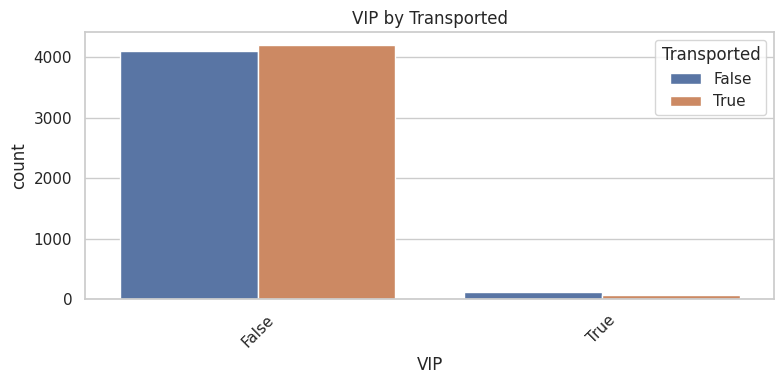

In [2]:
# 可視化: 各特徴量と Transport(または Transported) の関係を確認する
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid')

# データ読み込み
df = pd.read_csv('input/train.csv')
# ターゲット列を自動検出 (Transport, Transported など)
target_candidates = [c for c in df.columns if c.lower().startswith('transport')]
if not target_candidates:
    raise KeyError(f"No column starting with 'transport' found in train.csv. Columns: {list(df.columns)}")
target_col = target_candidates[0]
df[target_col] = df[target_col].astype('category')

# Transport の分布
plt.figure(figsize=(4,4))
sns.countplot(x=target_col, data=df)
plt.title(f'{target_col} counts')
plt.show()

# 数値特徴量とカテゴリ特徴量を自動判定
exclude = ['PassengerId', target_col]
num_cols = df.select_dtypes(include=['number']).columns.difference(exclude)
cat_cols = df.select_dtypes(include=['object','category']).columns.difference(exclude)

# 数値特徴量: ヒストグラム（ターゲットごとに色分け）
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(data=df, x=col, hue=target_col, multiple='stack', kde=False)
    plt.title(f'{col} by {target_col}')
    plt.tight_layout()
    plt.show()

# カテゴリ特徴量: カウントプロット（ユニーク値が多すぎる列は上位を表示）
for col in cat_cols:
    n_uni = df[col].nunique()
    plt.figure(figsize=(8,4))
    if n_uni > 20:
        top_vals = df[col].value_counts().nlargest(20).index
        sns.countplot(data=df[df[col].isin(top_vals)], x=col, hue=target_col, order=top_vals)
        plt.title(f'{col} (top 20) by {target_col}')
    else:
        sns.countplot(data=df, x=col, hue=target_col, order=df[col].value_counts().index)
        plt.title(f'{col} by {target_col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()